## Step 1: Setup - Clone Repository

In [1]:
# Clone your repository (replace with your actual GitHub URL)
# For now, we'll create the files directly

import os
os.makedirs('medical-detection-testing/utils', exist_ok=True)
os.makedirs('medical-detection-testing/results', exist_ok=True)
%cd medical-detection-testing

/content/medical-detection-testing


## Step 2: Install Requirements

In [2]:
!pip install -q numpy scikit-learn matplotlib seaborn pandas
print("✅ All packages installed!")

✅ All packages installed!


## Step 3: Create Medical Metrics Module

In [3]:
%%writefile utils/medical_metrics.py
"""Medical Metrics - MURA/FracAtlas methodology"""
import numpy as np
from sklearn.metrics import confusion_matrix, cohen_kappa_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

class MedicalMetrics:
    def __init__(self):
        self.reset()

    def reset(self):
        self.all_predictions = []
        self.all_labels = []
        self.all_probabilities = []

    def update(self, predictions, labels, probabilities=None):
        self.all_predictions.extend(predictions.flatten().tolist())
        self.all_labels.extend(labels.flatten().tolist())
        if probabilities is not None:
            self.all_probabilities.extend(probabilities.flatten().tolist())

    def calculate_all_metrics(self):
        tn, fp, fn, tp = confusion_matrix(self.all_labels, self.all_predictions).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = sensitivity
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        kappa = cohen_kappa_score(self.all_labels, self.all_predictions)

        metrics = {
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'accuracy': accuracy,
            'cohen_kappa': kappa,
        }

        if len(self.all_probabilities) > 0:
            try:
                metrics['auroc'] = roc_auc_score(self.all_labels, self.all_probabilities)
            except:
                pass

        return metrics

    def get_confusion_matrix(self):
        return confusion_matrix(self.all_labels, self.all_predictions)

    def print_metrics_report(self, model_name="Model"):
        metrics = self.calculate_all_metrics()
        cm = self.get_confusion_matrix()
        tn, fp, fn, tp = cm.ravel()

        print("\n" + "="*70)
        print(f"EVALUATION RESULTS - {model_name}")
        print("="*70)
        print(f"\nConfusion Matrix:")
        print(f"  TN: {tn:>6d}  |  FP: {fp:>6d}")
        print(f"  FN: {fn:>6d}  |  TP: {tp:>6d}")
        print(f"\nMetrics:")
        print(f"  Sensitivity:  {metrics['sensitivity']:.4f}")
        print(f"  Specificity:  {metrics['specificity']:.4f}")
        print(f"  Precision:    {metrics['precision']:.4f}")
        print(f"  F1-Score:     {metrics['f1_score']:.4f}")
        print(f"  Accuracy:     {metrics['accuracy']:.4f}")
        print(f"  Cohen's Kappa: {metrics['cohen_kappa']:.4f}")
        if 'auroc' in metrics:
            print(f"  AUROC:        {metrics['auroc']:.4f}")
        print("="*70 + "\n")

    def plot_roc_curve(self, save_path=None, model_name="Model"):
        if len(self.all_probabilities) == 0:
            print("⚠️ No probabilities available for ROC curve")
            return

        fpr, tpr, _ = roc_curve(self.all_labels, self.all_probabilities)
        auroc = roc_auc_score(self.all_labels, self.all_probabilities)

        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auroc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
        plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
        plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
        plt.title(f'ROC Curve - {model_name}', fontsize=14)
        plt.legend(loc='lower right', fontsize=10)
        plt.grid(True, alpha=0.3)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
        else:
            plt.show()

    def plot_confusion_matrix(self, save_path=None, model_name="Model"):
        cm = self.get_confusion_matrix()

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Normal', 'Abnormal'],
                   yticklabels=['Normal', 'Abnormal'])
        plt.ylabel('True Label', fontsize=12)
        plt.xlabel('Predicted Label', fontsize=12)
        plt.title(f'Confusion Matrix - {model_name}', fontsize=14)

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.close()
        else:
            plt.show()

def bootstrap_metrics(predictions, labels, n_bootstrap=1000):
    n_samples = len(predictions)
    results = {'sensitivity': [], 'specificity': [], 'cohen_kappa': [], 'accuracy': []}

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        boot_pred = predictions[indices]
        boot_labels = labels[indices]

        tn, fp, fn, tp = confusion_matrix(boot_labels, boot_pred).ravel()

        results['sensitivity'].append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
        results['specificity'].append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
        results['accuracy'].append((tp + tn) / (tp + tn + fp + fn))
        results['cohen_kappa'].append(cohen_kappa_score(boot_labels, boot_pred))

    final_results = {}
    for metric_name, values in results.items():
        mean_val = np.mean(values)
        lower_ci = np.percentile(values, 2.5)
        upper_ci = np.percentile(values, 97.5)
        final_results[metric_name] = (mean_val, lower_ci, upper_ci)

    return final_results

Writing utils/medical_metrics.py


## Step 4: Run Demo Test

In [4]:
import numpy as np
import json
from utils.medical_metrics import MedicalMetrics, bootstrap_metrics

print("🚀 Starting Demo Test...\n")

# Generate synthetic data
num_samples = 100
np.random.seed(42)

# Simulate true labels (60% normal, 40% abnormal)
true_labels = np.random.choice([0, 1], size=num_samples, p=[0.6, 0.4])

# Simulate model predictions with ~90% accuracy
predictions = true_labels.copy()
error_indices = np.random.choice(num_samples, size=int(num_samples * 0.1), replace=False)
predictions[error_indices] = 1 - predictions[error_indices]

# Generate probabilities
probabilities = np.zeros(num_samples)
for i in range(num_samples):
    if predictions[i] == 1:
        probabilities[i] = np.random.uniform(0.6, 0.99)
    else:
        probabilities[i] = np.random.uniform(0.01, 0.4)

print(f"✅ Generated {num_samples} synthetic samples")
print(f"   Normal (0): {np.sum(true_labels == 0)}")
print(f"   Abnormal (1): {np.sum(true_labels == 1)}")

🚀 Starting Demo Test...

✅ Generated 100 synthetic samples
   Normal (0): 63
   Abnormal (1): 37


## Step 5: Calculate Metrics

In [5]:
# Initialize metrics calculator
metrics_calc = MedicalMetrics()

# Update with data
metrics_calc.update(
    predictions=predictions,
    labels=true_labels,
    probabilities=probabilities
)

# Calculate and print
metrics = metrics_calc.calculate_all_metrics()
metrics_calc.print_metrics_report(model_name="RetinaNet (DEMO)")


EVALUATION RESULTS - RetinaNet (DEMO)

Confusion Matrix:
  TN:     59  |  FP:      4
  FN:      6  |  TP:     31

Metrics:
  Sensitivity:  0.8378
  Specificity:  0.9365
  Precision:    0.8857
  F1-Score:     0.8611
  Accuracy:     0.9000
  Cohen's Kappa: 0.7831
  AUROC:        0.8636



## Step 6: Visualize Results

📈 Generating ROC Curve...


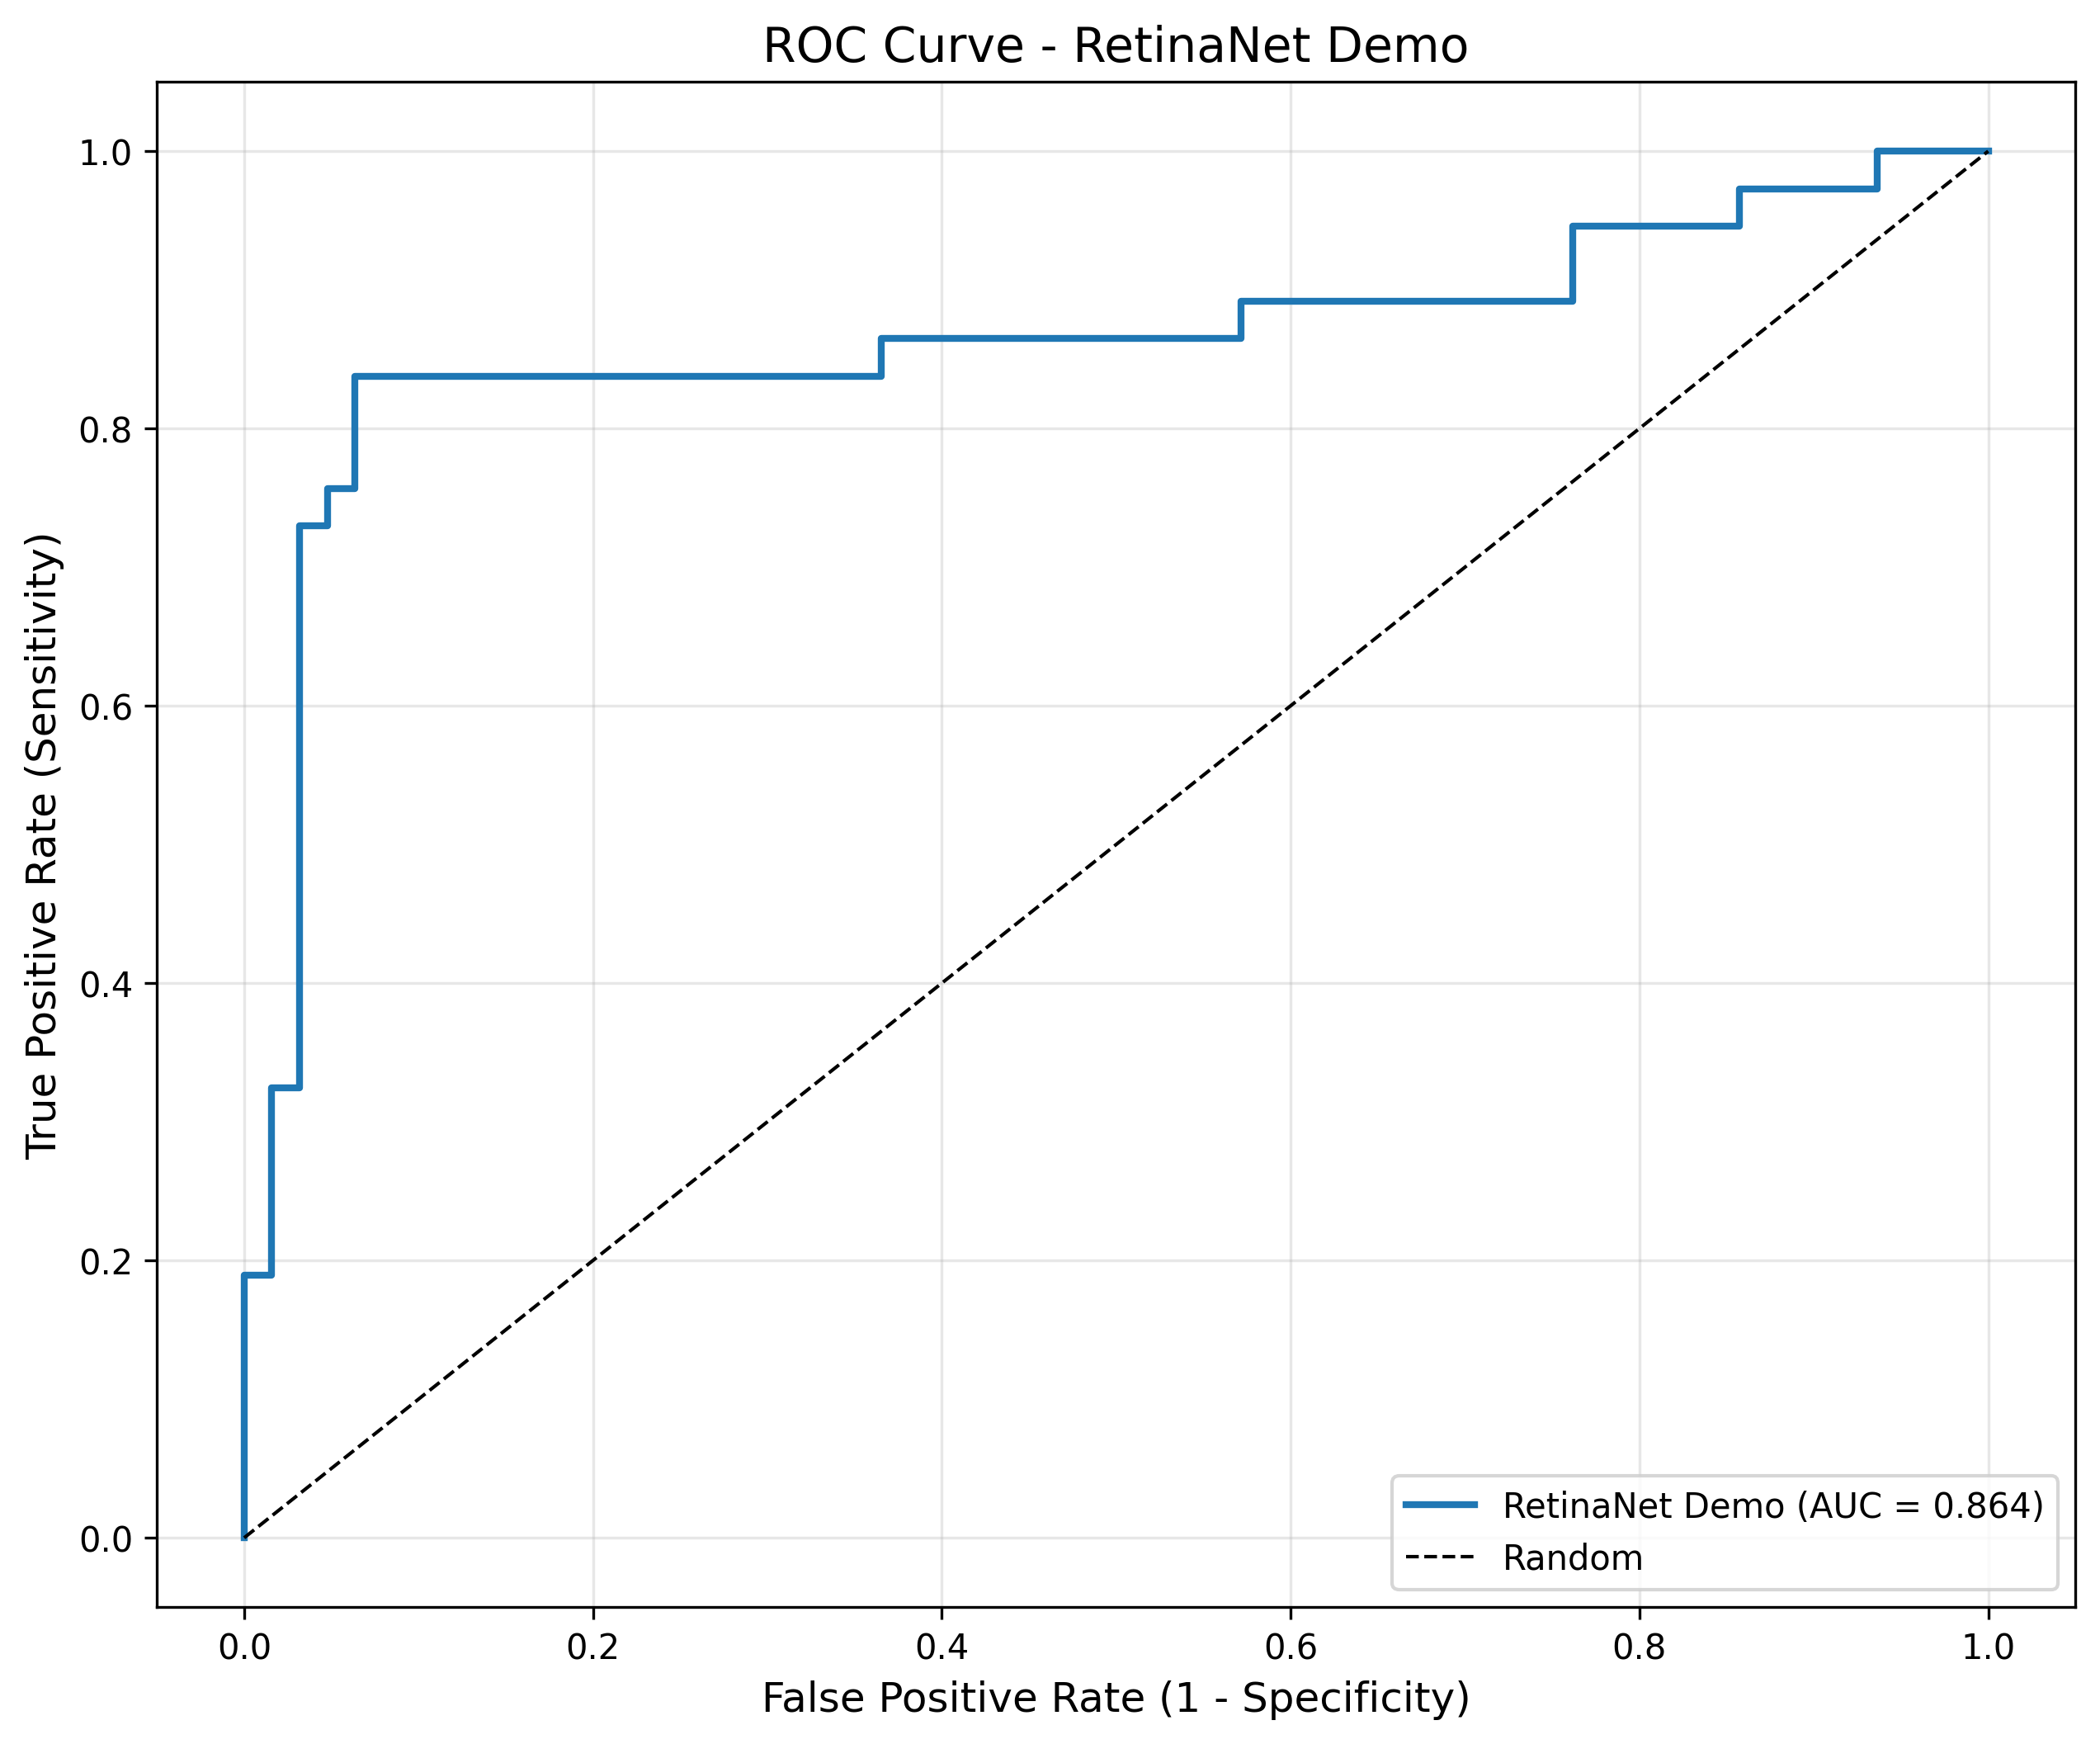

In [6]:
# Plot ROC Curve
print("📈 Generating ROC Curve...")
metrics_calc.plot_roc_curve(save_path='results/roc_curve_demo.png', model_name="RetinaNet Demo")

# Display inline
from IPython.display import Image, display
display(Image('results/roc_curve_demo.png'))

📊 Generating Confusion Matrix...


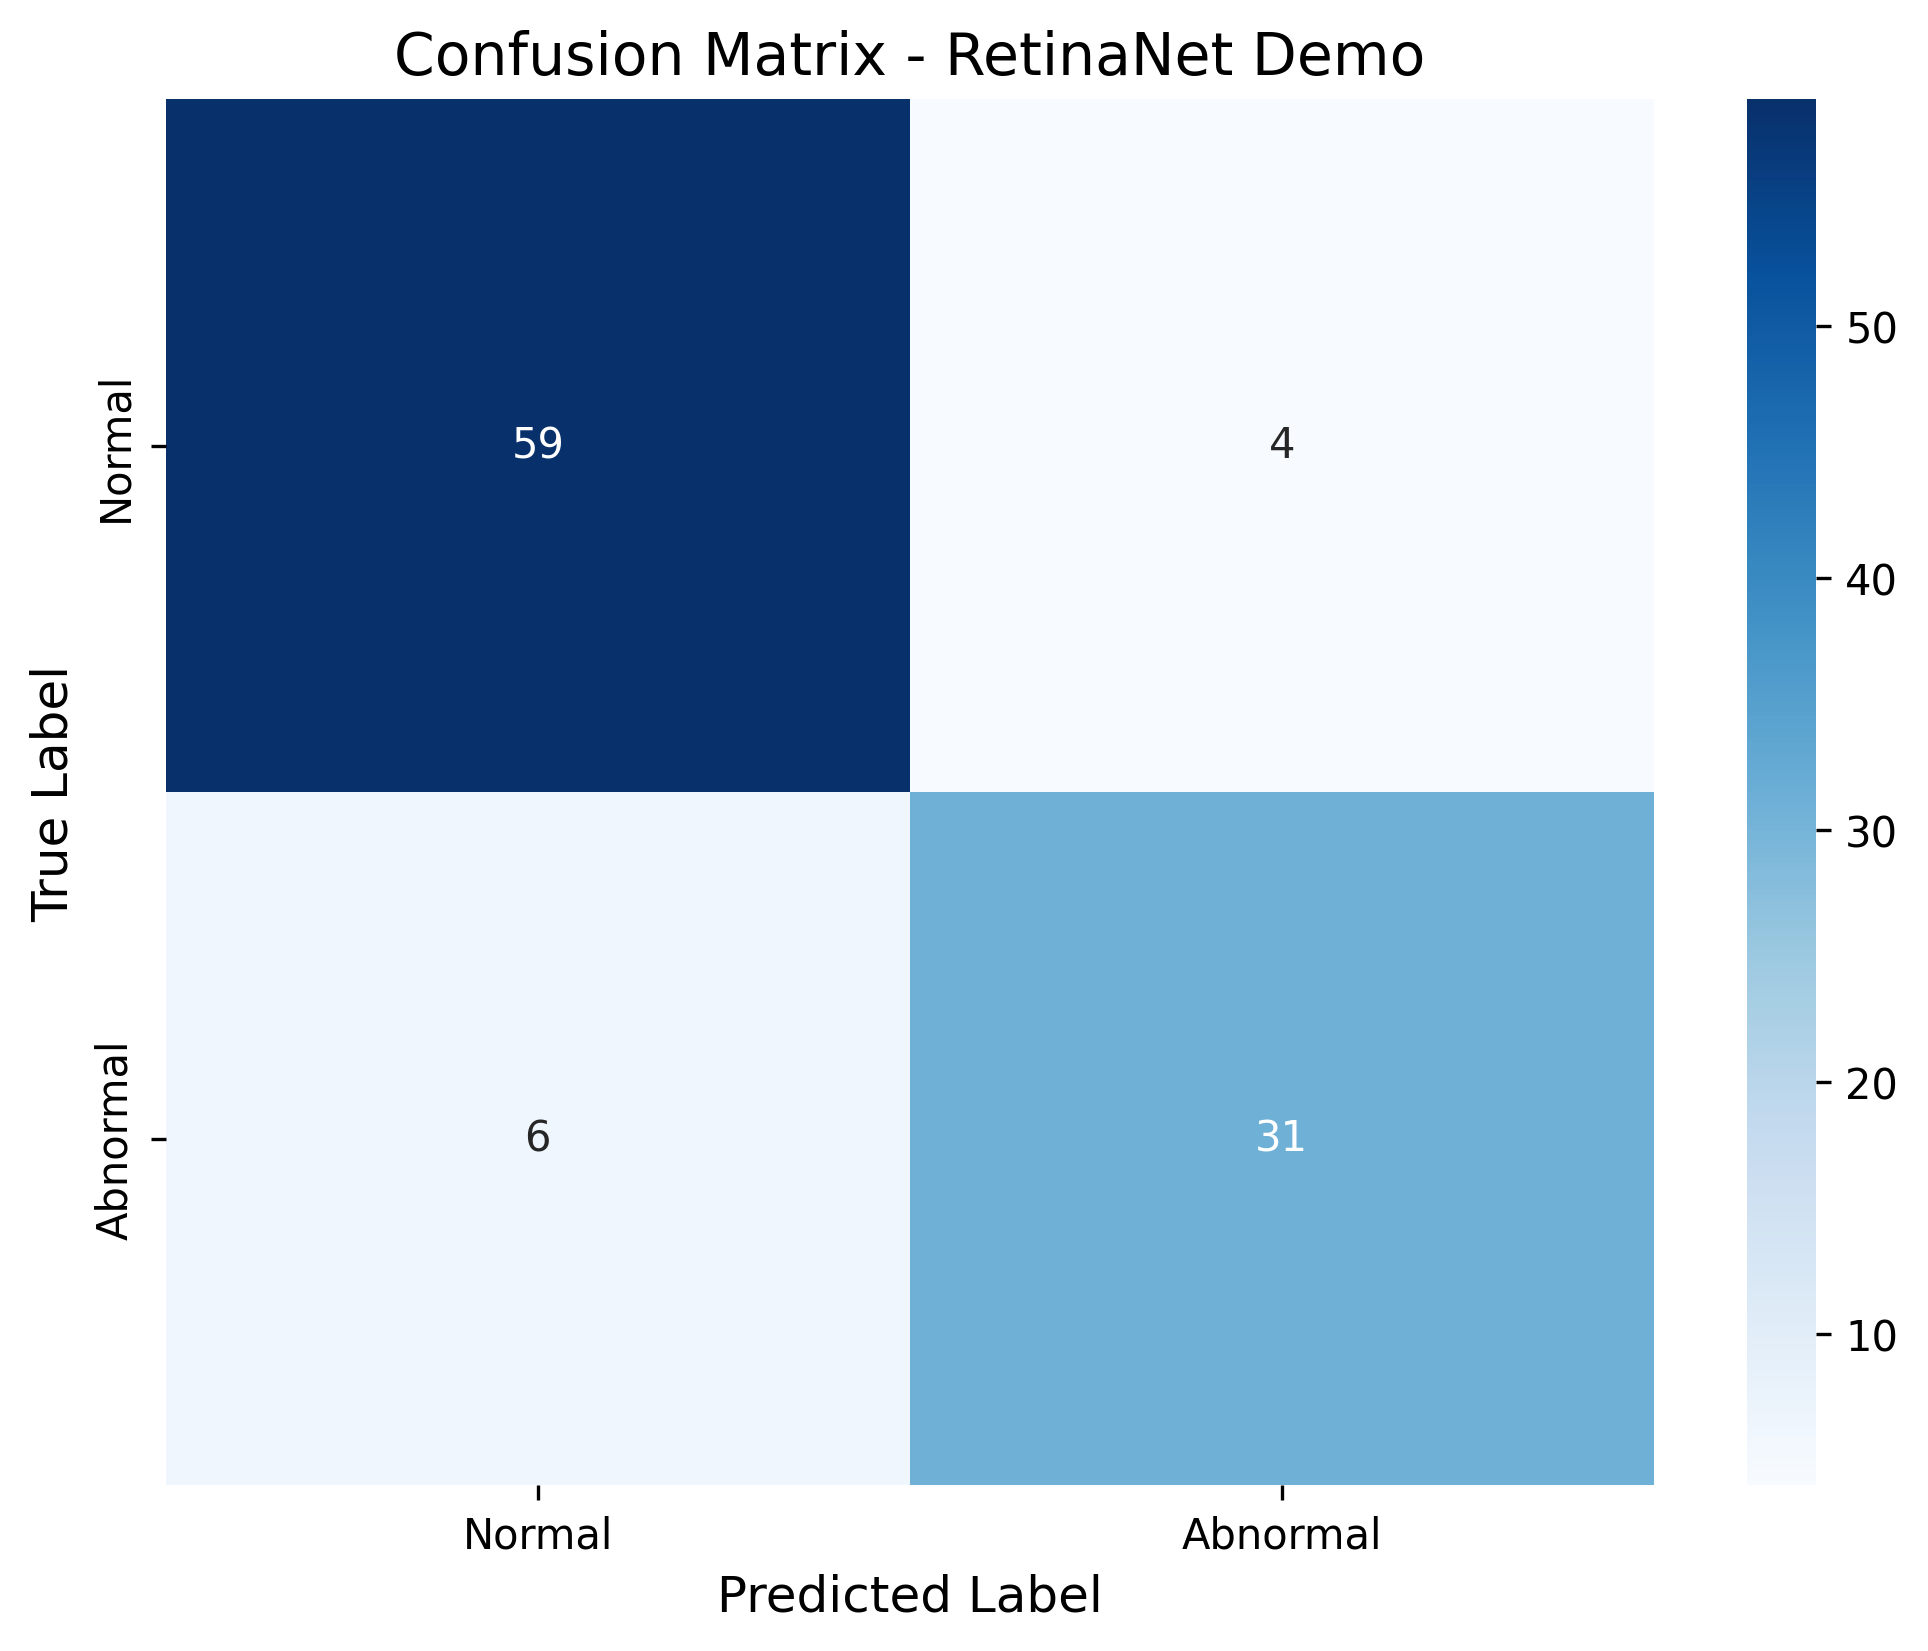

In [7]:
# Plot Confusion Matrix
print("📊 Generating Confusion Matrix...")
metrics_calc.plot_confusion_matrix(save_path='results/confusion_matrix_demo.png', model_name="RetinaNet Demo")

# Display inline
display(Image('results/confusion_matrix_demo.png'))

## Step 7: Calculate Confidence Intervals (95% CI)

In [8]:
print("🔄 Calculating 95% Confidence Intervals (1000 bootstrap samples)...")
ci_results = bootstrap_metrics(predictions, true_labels, n_bootstrap=1000)

print("\n📊 Metrics with 95% Confidence Intervals:")
print("-" * 70)
for metric_name, (mean, lower, upper) in ci_results.items():
    print(f"  {metric_name:20s}: {mean:.4f} (95% CI: {lower:.4f}, {upper:.4f})")
print("-" * 70)

🔄 Calculating 95% Confidence Intervals (1000 bootstrap samples)...

📊 Metrics with 95% Confidence Intervals:
----------------------------------------------------------------------
  sensitivity         : 0.8391 (95% CI: 0.7111, 0.9512)
  specificity         : 0.9377 (95% CI: 0.8750, 0.9846)
  cohen_kappa         : 0.7837 (95% CI: 0.6387, 0.8971)
  accuracy            : 0.9010 (95% CI: 0.8400, 0.9500)
----------------------------------------------------------------------


## Step 8: Save Results

In [9]:
# Save to JSON
results = {
    'model': 'RetinaNet (DEMO)',
    'mode': 'synthetic_data_colab',
    'num_samples': int(num_samples),
    'metrics': {k: float(v) for k, v in metrics.items()},
    'confidence_intervals': {
        k: {'mean': float(v[0]), 'lower_ci': float(v[1]), 'upper_ci': float(v[2])}
        for k, v in ci_results.items()
    },
    'confusion_matrix': metrics_calc.get_confusion_matrix().tolist(),
}

with open('results/demo_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Results saved to results/demo_results.json")

✅ Results saved to results/demo_results.json


## Step 9: Download Results

In [10]:
# Download files
from google.colab import files

print("📥 Downloading result files...")
files.download('results/demo_results.json')
files.download('results/roc_curve_demo.png')
files.download('results/confusion_matrix_demo.png')

print("✅ All files downloaded!")

📥 Downloading result files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
